In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

data_dir = "../dataset_skin_capstone"

In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 1200 images belonging to 3 classes.
Found 299 images belonging to 3 classes.
{'dry': 0, 'normal': 1, 'oily': 2}


In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 loại da
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.5567 - loss: 0.9876 - val_accuracy: 0.5886 - val_loss: 0.9282
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.6533 - loss: 0.8075 - val_accuracy: 0.6656 - val_loss: 0.7869
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6867 - loss: 0.7259 - val_accuracy: 0.6555 - val_loss: 0.7863
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7200 - loss: 0.6627 - val_accuracy: 0.6722 - val_loss: 0.7701
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7333 - loss: 0.6359 - val_accuracy: 0.7157 - val_loss: 0.7557
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7817 - loss: 0.5655 - val_accuracy: 0.7191 - val_loss: 0.7243
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7950 - loss: 0.5360 - val_accuracy: 0.7090 - val_loss: 0.7317
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7975 - loss: 0.5178 - val_accuracy: 0.6656 - val_loss

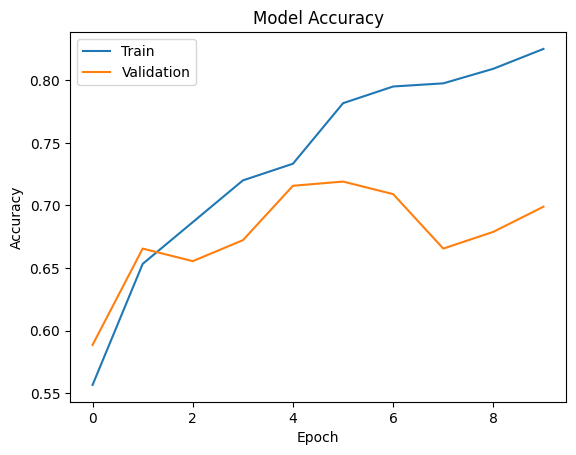

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
model.save("model.keras")
print("Model saved!")

Model saved!


In [38]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = list(train_data.class_indices.keys())

img_path = "test12.jpg"

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
pred_class = class_names[np.argmax(prediction)]

print("Kết quả dự đoán:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Kết quả dự đoán: dry


In [29]:
# Đánh giá trên tập validation
val_loss, val_acc = model.evaluate(val_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 679ms/step - accuracy: 0.7090 - loss: 0.7374
Validation Loss: 0.737430214881897
Validation Accuracy: 0.7090300917625427


In [30]:
import numpy as np

# Reset generator để tránh lệch batch
val_data.reset()

# Dự đoán
pred_probs = model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)

# Nhãn thật
true_classes = val_data.classes

# Tên lớp
class_names = list(val_data.class_indices.keys())
print(class_names)

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
['dry', 'normal', 'oily']


In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

         dry       0.35      0.39      0.37       100
      normal       0.32      0.23      0.27        99
        oily       0.39      0.45      0.42       100

    accuracy                           0.36       299
   macro avg       0.35      0.36      0.35       299
weighted avg       0.35      0.36      0.35       299



In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

print(cm)

[[39 23 38]
 [45 23 31]
 [29 26 45]]


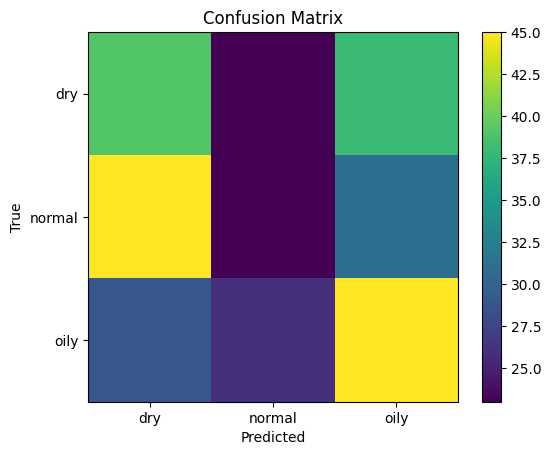

In [33]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

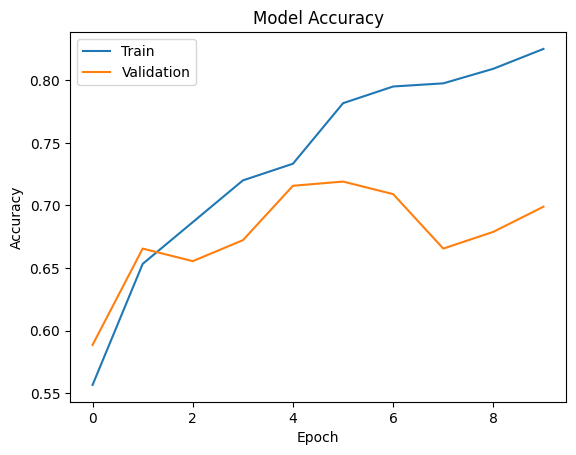

In [34]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

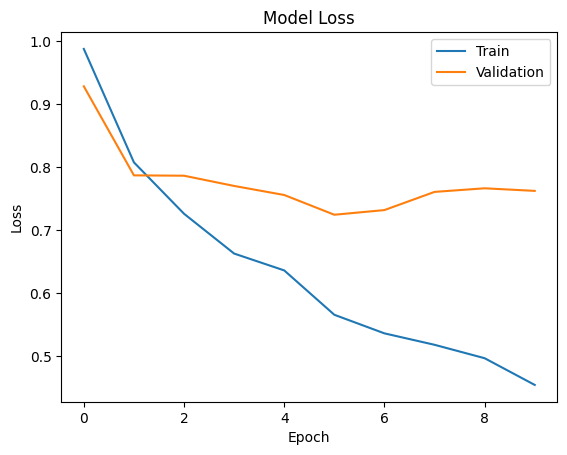

In [35]:
# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()